## Additional Plots, and useful functions to visualize data...

In [30]:
# data path 
data = "/home/asalmona/Documents/Ricci/code/__some_results/exp3/model_10-54-06-MERFISH_epoch_249/mouse2_slice300_0/metadata_true.csv"

# imports 
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def plot_cells_by_type(
    csv_path,
    cell_types,
    ax=None,
    dot_size=6,
    highlighted_dot_size=10,
    alpha=0.85,
    other_color="black",
    cmap_name="gist_rainbow",
):
    """Plot cells in the XY plane, highlighting selected cell types by color.

    Parameters
    ----------
    csv_path : str or pathlib.Path
        CSV file containing cell metadata.
    cell_types : list[str]
        Cell classes to highlight with distinct colors. Cells with classes not in
        this list are plotted in `other_color`.
    ax : matplotlib.axes.Axes, optional
        Existing axes to draw on. If not provided, a new figure and axes are made.
    dot_size : float, default 6
        Marker size for cells whose class is not in `cell_types`.
    highlighted_dot_size : float, default 18
        Marker size for cells whose class is in `cell_types`.
    alpha : float, default 0.85
        Marker transparency.
    other_color : str, default "black"
        Color used for cells whose class is not in `cell_types`.
    cmap_name : str, default "gist_rainbow"
        Bright Matplotlib colormap used to assign colors to selected cell types.

    Returns
    -------
    fig, ax
        The matplotlib figure and axes containing the plot.
    """
    df = pd.read_csv(Path(csv_path))
    required_columns = {"cell_class", "coord_X", "coord_Y"}
    missing_columns = required_columns.difference(df.columns)
    if missing_columns:
        raise ValueError(f"Missing required columns: {sorted(missing_columns)}")

    cell_types = list(cell_types)
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 7))
    else:
        fig = ax.figure

    selected_mask = df["cell_class"].isin(cell_types)
    other_cells = df.loc[~selected_mask]
    if not other_cells.empty:
        ax.scatter(
            other_cells["coord_X"],
            other_cells["coord_Y"],
            s=dot_size,
            c=other_color,
            alpha=alpha,
            linewidths=0,
            label="Other cell types",
        )

    cmap = plt.get_cmap(cmap_name, max(len(cell_types), 1))
    for idx, cell_type in enumerate(cell_types):
        cells = df.loc[df["cell_class"] == cell_type]
        if cells.empty:
            continue

        ax.scatter(
            cells["coord_X"],
            cells["coord_Y"],
            s=highlighted_dot_size,
            color=cmap(idx),
            alpha=alpha,
            linewidths=0,
            label=cell_type,
        )

    ax.set_xlabel("coord_X")
    ax.set_ylabel("coord_Y")
    ax.set_aspect("equal", adjustable="box")
    ax.legend(markerscale=3, frameon=False, bbox_to_anchor=(1.04, 1), loc="upper left")
    ax.set_title("Cell locations by cell class")

    return fig, ax


In [31]:
# read data 
df = pd.read_csv(data)

In [32]:
# list cell types from data
cell_types = df["cell_class"].unique()
print(cell_types)

['Oligo' 'Astro' 'L6 CT' 'L5 IT' 'L5 ET' 'OPC' 'L6 IT' 'VLMC' 'L2/3 IT'
 'L4/5 IT' 'SMC' 'Endo' 'Lamp5' 'PVM' 'Peri' 'Micro' 'L6b' 'L5/6 NP'
 'Pvalb' 'Vip' 'Sst' 'Sncg']


(<Figure size 700x700 with 1 Axes>,
 <Axes: title={'center': 'Cell locations by cell class'}, xlabel='coord_X', ylabel='coord_Y'>)

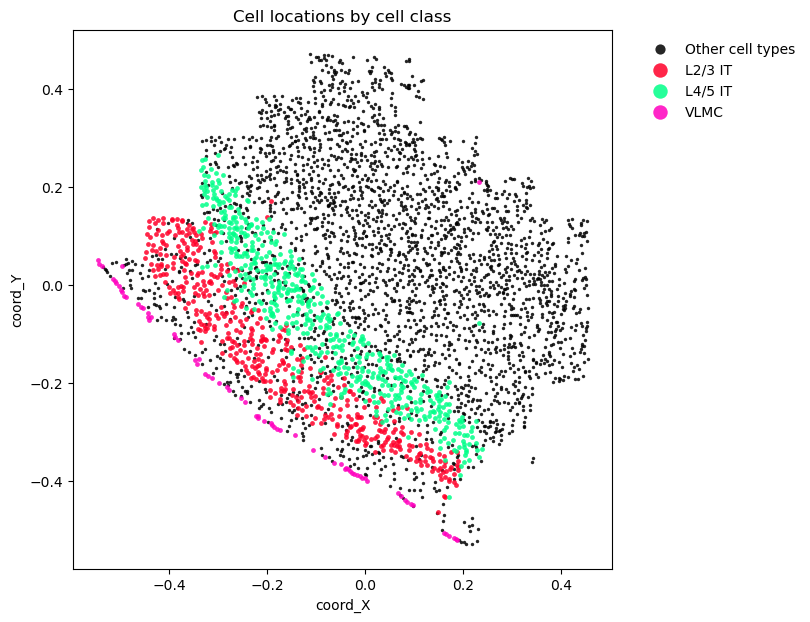

In [33]:
# plot layers 
layers = [ 'L2/3 IT', 'L4/5 IT', 'VLMC']

# plot layers 
plot_cells_by_type(data, layers, highlighted_dot_size=12)


(<Figure size 700x700 with 1 Axes>,
 <Axes: title={'center': 'Cell locations by cell class'}, xlabel='coord_X', ylabel='coord_Y'>)

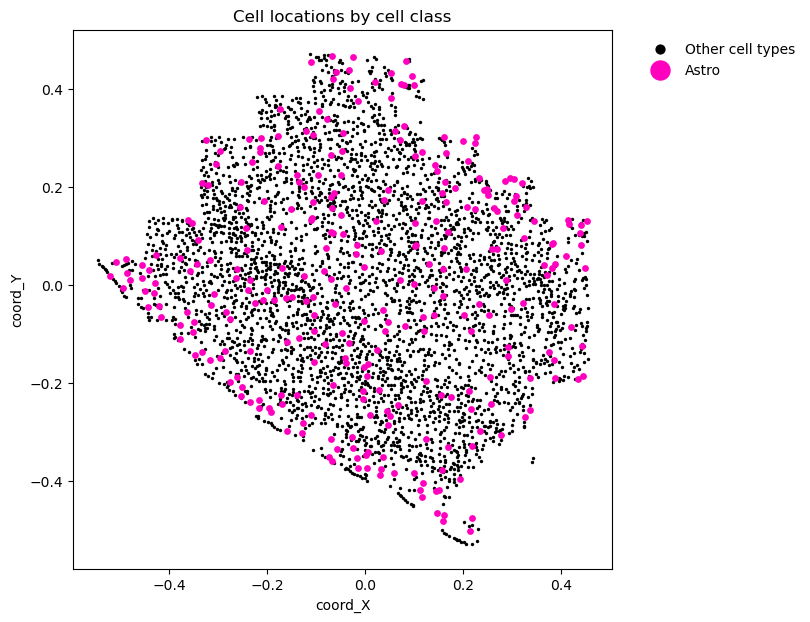

In [ ]:
# plot layers 
layers = ['L5/6 NP'] #, 'Endo', 'Micro']

# plot layers 
plot_cells_by_type(data, layers, highlighted_dot_size=24, alpha=1.0)

(<Figure size 700x700 with 1 Axes>,
 <Axes: title={'center': 'Cell locations by cell class'}, xlabel='coord_X', ylabel='coord_Y'>)

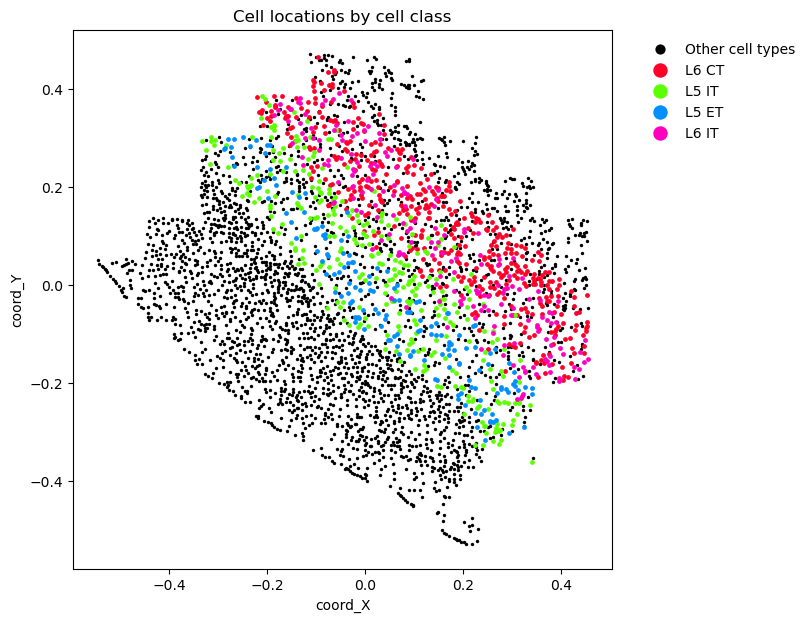

In [35]:
layers = ['L6 CT', 'L5 IT', 'L5 ET', 'L6 IT']# plot layers 
plot_cells_by_type(data, layers, highlighted_dot_size=12, alpha=1.0)

In [36]:
# plot the number of cells from one type

type = "L4/5 IT"

print(df[df["cell_class"] == type])



      Unnamed: 0 cell_class   coord_X   coord_Y
17        133408    L4/5 IT -0.297211  0.172030
23         91496    L4/5 IT -0.139621 -0.060431
24        104008    L4/5 IT -0.186321  0.043351
40        103406    L4/5 IT  0.080366 -0.271793
49         55536    L4/5 IT -0.133472  0.031751
...          ...        ...       ...       ...
3759      232075    L4/5 IT -0.108722  0.021623
3767       43714    L4/5 IT  0.076579 -0.248894
3771      175160    L4/5 IT -0.269535  0.133462
3775      175153    L4/5 IT -0.290412  0.224805
3777      233211    L4/5 IT -0.297442  0.165464

[558 rows x 4 columns]
